In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [45]:
df = pd.read_csv("Scores.csv", sep=';')
df

,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23
1,2,id_001,female,high school,language,40
2,3,id_002,female,high school,math,68
3,4,id_002,female,high school,language,"80,5"
4,5,id_003,male,high school,math,82
...,...,...,...,...,...,...
967,968,id_484,female,master's degree,language,"93,5"
968,969,id_485,female,master's degree,math,92
969,970,id_485,female,master's degree,language,100
970,971,id_486,female,master's degree,math,88


In [46]:
missing_data = df.isnull().sum()
print("Missing Values:\n", missing_data)

Missing Values:
 Unnamed: 0                     0
student_id                     0
gender                         0
parental.level.of.education    0
subject                        0
score                          0
dtype: int64


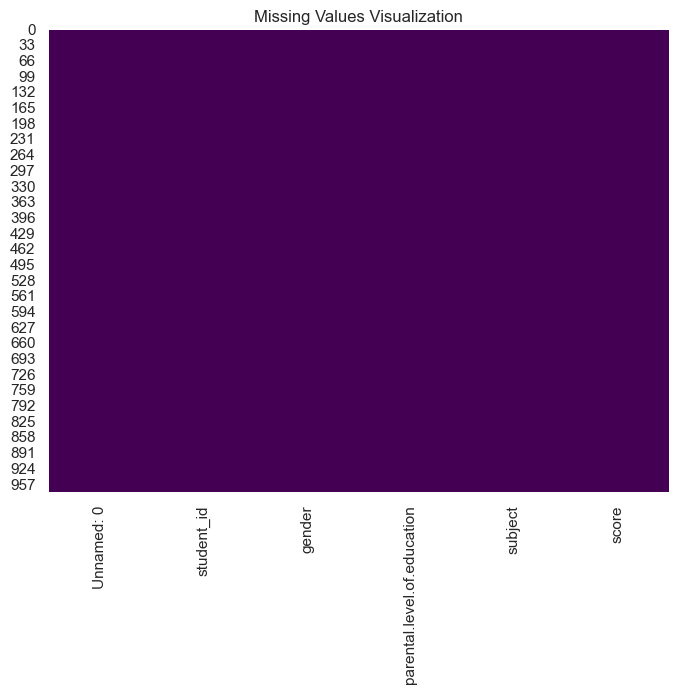

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Visualization')
plt.show()

In [48]:
math_df = df[df['subject'] == 'math'].copy()
lang_df = df[df['subject'] == 'language'].copy()

In [21]:
math_df

,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23
2,3,id_002,female,high school,math,68
4,5,id_003,male,high school,math,82
6,7,id_004,female,high school,math,58
8,9,id_005,female,high school,math,60
...,...,...,...,...,...,...
962,963,id_482,female,master's degree,math,73
964,965,id_483,male,master's degree,math,72
966,967,id_484,female,master's degree,math,78
968,969,id_485,female,master's degree,math,92


In [49]:
lang_df

,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
1,2,id_001,female,high school,language,40
3,4,id_002,female,high school,language,"80,5"
5,6,id_003,male,high school,language,81
7,8,id_004,female,high school,language,"60,5"
9,10,id_005,female,high school,language,69
...,...,...,...,...,...,...
963,964,id_482,female,master's degree,language,76
965,966,id_483,male,master's degree,language,69
967,968,id_484,female,master's degree,language,"93,5"
969,970,id_485,female,master's degree,language,100


In [51]:
df['score'] = pd.to_numeric(df['score'].astype(str).str.replace(',', '.'), errors='coerce')

In [52]:
if df['score'].isnull().any():
    print(f"Warning: {df['score'].isnull().sum()} rows could not be converted and are now NaN.")
    df = df.dropna(subset=['score'])

In [53]:
math_df = df[df['subject'] == 'math'].copy()
lang_df = df[df['subject'] == 'language'].copy()

In [54]:
math_df

,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23.0
2,3,id_002,female,high school,math,68.0
4,5,id_003,male,high school,math,82.0
6,7,id_004,female,high school,math,58.0
8,9,id_005,female,high school,math,60.0
...,...,...,...,...,...,...
962,963,id_482,female,master's degree,math,73.0
964,965,id_483,male,master's degree,math,72.0
966,967,id_484,female,master's degree,math,78.0
968,969,id_485,female,master's degree,math,92.0


In [55]:
lang_df

,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
1,2,id_001,female,high school,language,40.0
3,4,id_002,female,high school,language,80.5
5,6,id_003,male,high school,language,81.0
7,8,id_004,female,high school,language,60.5
9,10,id_005,female,high school,language,69.0
...,...,...,...,...,...,...
963,964,id_482,female,master's degree,language,76.0
965,966,id_483,male,master's degree,language,69.0
967,968,id_484,female,master's degree,language,93.5
969,970,id_485,female,master's degree,language,100.0


In [56]:
max_math_score = math_df['score'].max()
max_lang_score = lang_df['score'].max()

In [57]:
print(max_lang_score)
print(max_math_score)

100.0
100.0


In [58]:
min_math_score = math_df['score'].min()
min_lang_score = lang_df['score'].min()

In [59]:
print(min_lang_score)
print(min_math_score)

19.5
23.0


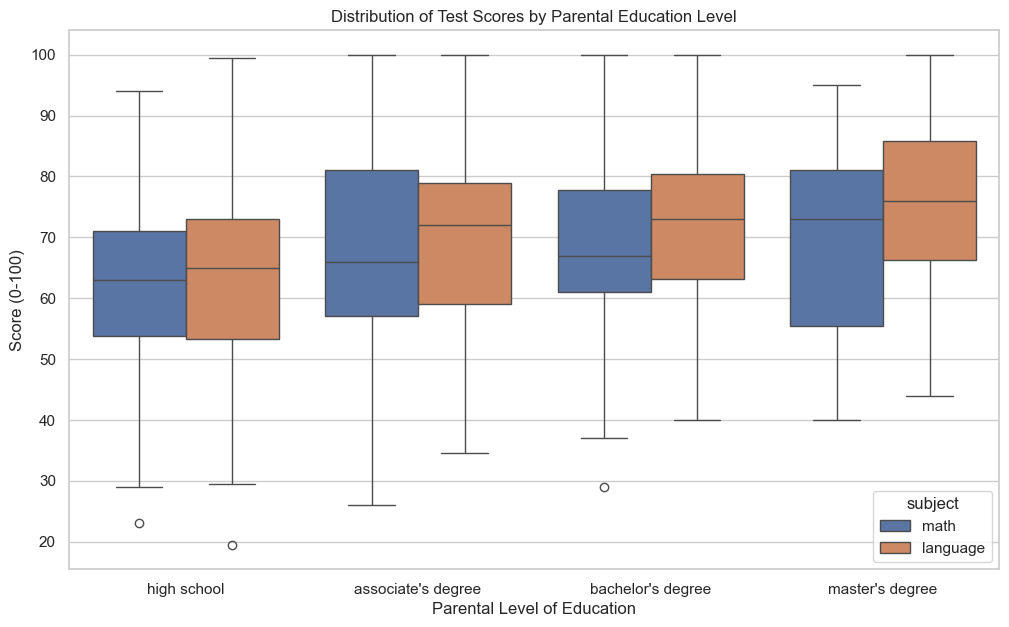

In [60]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))
# Boxplot showing both subjects side-by-side across education levels
sns.boxplot(data=df, x='parental.level.of.education', y='score', hue='subject',
            order=["high school", "associate's degree", "bachelor's degree", "master's degree"])
plt.title('Distribution of Test Scores by Parental Education Level')
plt.ylabel('Score (0-100)')
plt.xlabel('Parental Level of Education')
plt.savefig('scores_boxplot.png') # This image is ready for your report

In [61]:
# 5. Hypothesis Testing (Task b)
# Q1: Gender Differences (Independent T-Test)
t_math, p_math = stats.ttest_ind(math_df[math_df['gender'] == 'male']['score'], 
                                 math_df[math_df['gender'] == 'female']['score'])

t_lang, p_lang = stats.ttest_ind(lang_df[lang_df['gender'] == 'male']['score'], 
                                 lang_df[lang_df['gender'] == 'female']['score'])

print(f"\n--- Gender T-Test Results ---")
print(f"Math: t={t_math:.4f}, p={p_math:.4e}")
print(f"Language: t={t_lang:.4f}, p={p_lang:.4e}")

# Q2: Parental Education Differences (One-Way ANOVA)
# Preparing groups for ANOVA
groups_math = [group['score'].values for name, group in math_df.groupby('parental.level.of.education')]
f_math, p_f_math = stats.f_oneway(*groups_math)

print(f"\n--- Parental Education ANOVA (Math) ---")
print(f"F-statistic={f_math:.4f}, p-value={p_f_math:.4e}")

# Post-hoc test (Tukey HSD) to see WHICH groups differ
if p_f_math < 0.05:
    print("\n--- Tukey HSD Post-hoc Test (Math) ---")
    tukey = pairwise_tukeyhsd(endog=math_df['score'], 
                              groups=math_df['parental.level.of.education'], 
                              alpha=0.05)
    print(tukey.summary())


--- Gender T-Test Results ---
Math: t=3.7765, p=1.7884e-04
Language: t=-6.4087, p=3.4876e-10

--- Parental Education ANOVA (Math) ---
F-statistic=6.2229, p-value=3.7509e-04

--- Tukey HSD Post-hoc Test (Math) ---
            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------
